# single_wg_mode.ipynb

Single 220 nm silicon waveguide mode analysis using Lumerical MODE/FDE.

Workflow:

1. Check Palik material dispersion for Si and SiO2 from 1500 nm to 1600 nm.
2. Build a 220 nm thick silicon strip waveguide inside a SiO2 box.
3. Add a 2D FDE region.
4. Choose boundary condition: PML or Metal.
5. Optionally add local extra mesh around the waveguide.
6. Solve modes.
7. Extract neff, group index, loss, TE fraction, E/H fields, index map, Sz, mode area, and MFD.

## Imports and Lumerical API path

In [50]:
import os
import sys
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this to your Lumerical installation path
# Examples:
# r"C:\Program Files\Lumerical\v242\api\python"
# r"C:\Program Files\AnsysEM\v251\Lumerical\api\python"
# r"C:\Program Files\Lumerical\v261\api\python"

LUMERICAL_PYTHON_API = r"C:\Program Files\Lumerical\v261\api\python"

if not os.path.isdir(LUMERICAL_PYTHON_API):
    raise FileNotFoundError(
        f"Lumerical Python API folder not found:\n{LUMERICAL_PYTHON_API}"
    )

if LUMERICAL_PYTHON_API not in sys.path:
    sys.path.append(LUMERICAL_PYTHON_API)

import lumapi

print("lumapi imported successfully")

lumapi imported successfully


## Settings cell

In [51]:
settings = {
    # ------------------------------------------------------------------
    # Built-in Lumerical Palik materials
    # ------------------------------------------------------------------
    "si_material_name": "Si (Silicon) - Palik",
    "sio2_material_name": "SiO2 (Glass) - Palik",

    # ------------------------------------------------------------------
    # Material fitting range, like Material Explorer / MODE MCM fit
    # ------------------------------------------------------------------
    "material_fit_min_nm": 1200.0,
    "material_fit_max_nm": 1700.0,

    # ------------------------------------------------------------------
    # Design wavelength range for plotting and material analysis
    # ------------------------------------------------------------------
    "lambda_min_nm": 1500.0,
    "lambda_max_nm": 1600.0,
    "lambda_points": 501,

    # ------------------------------------------------------------------
    # Main simulation wavelength
    # ------------------------------------------------------------------
    "wavelength_um": 1.55,

    # ------------------------------------------------------------------
    # Waveguide geometry
    # Propagation direction = z
    # Cross section = x-y
    # ------------------------------------------------------------------
    "wg_width_um": 0.300,
    "wg_thickness_um": 0.22,
    "wg_center_x_um": 0.0,
    "wg_center_y_um": 0.0,

    # ------------------------------------------------------------------
    # SiO2 surrounding box for FDE cross section
    # ------------------------------------------------------------------
    "oxide_x_span_um": 50.0,
    "oxide_y_span_um": 50.0,
    "z_span_um": 10.0,

    # ------------------------------------------------------------------
    # FDE region
    # ------------------------------------------------------------------
    "fde_x_span_um": 20.0,
    "fde_y_span_um": 20.0,
    "fde_center_x_um": 0.0,
    "fde_center_y_um": 0.0,

    # Options:
    # "PML"  -> final open-boundary mode calculation
    # "Metal" -> quick bounded test
    "fde_bc": "PML",

    # ------------------------------------------------------------------
    # FDE mesh
    # ------------------------------------------------------------------
    "fde_dx_um": 0.05,
    "fde_dy_um": 0.05,
    "number_of_trial_modes": 8,

    # ------------------------------------------------------------------
    # Optional extra mesh around waveguide
    # ------------------------------------------------------------------
    "use_extra_mesh": True,
    "extra_mesh_name": "mesh_wg",
    "mesh_factor_x": 3.0,
    "mesh_factor_y": 5.0,
    "local_dx_um": 0.01,
    "local_dy_um": 0.01,

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    "plot_window_x_um": (-2.0, 2.0),
    "plot_window_y_um": (-2.0, 2.0),
    "field_cut_x_um": 0.0,
    "field_cut_y_um": 0.0,
    "cmap": "jet",

    # Options:
    # "E2", "Sz", "W"
    "area_definition_for_metrics": "E2",

    # ------------------------------------------------------------------
    # Session
    # ------------------------------------------------------------------
    "hide_lumerical": False,

    # ------------------------------------------------------------------
    # Saving
    # ------------------------------------------------------------------
    "folder_name": "single_wg_mode",
    "simulation_file_name": "single_si_wg_fde"
}

um = 1e-6
c0 = 299792458.0
eps0 = 8.854187817e-12
mu0 = 4 * np.pi * 1e-7

## Helper checks

In [52]:
def check_boundary_condition_name(bc):
    allowed = ["PML", "Metal"]
    if bc not in allowed:
        raise ValueError(f"Invalid fde_bc = {bc}. Use one of {allowed}.")

check_boundary_condition_name(settings["fde_bc"])

if abs(settings["wg_thickness_um"] - 0.22) > 1e-12:
    raise ValueError("This notebook is intended for 220 nm Si thickness.")

if not (
    settings["material_fit_min_nm"]
    <= settings["lambda_min_nm"]
    < settings["lambda_max_nm"]
    <= settings["material_fit_max_nm"]
):
    raise ValueError(
        "The design wavelength range must be inside the material fit range."
    )

print("Settings are valid.")
print(f"Material fit range: {settings['material_fit_min_nm']}–{settings['material_fit_max_nm']} nm")
print(f"Design range: {settings['lambda_min_nm']}–{settings['lambda_max_nm']} nm")
print(f"Waveguide: {settings['wg_width_um']} um x {settings['wg_thickness_um']} um")
print(f"FDE boundary condition: {settings['fde_bc']}")

Settings are valid.
Material fit range: 1200.0–1700.0 nm
Design range: 1500.0–1600.0 nm
Waveguide: 0.3 um x 0.22 um
FDE boundary condition: PML


## Start MODE session

In [53]:
mode = lumapi.MODE(hide=settings["hide_lumerical"])
mode.newproject()

print("MODE session started.")

MODE session started.


## Check that Palik materials exist

In [54]:
mode.switchtolayout()

for mat in [settings["si_material_name"], settings["sio2_material_name"]]:
    try:
        mode.eval(f'test_material_data = getmaterial("{mat}", "sampled data");')
        raw = np.array(mode.getv("test_material_data"))
        print(f"Material found: {mat}")
        print("sampled data shape:", raw.shape)
    except Exception as e:
        raise RuntimeError(
            f"Could not read material sampled data for:\n{mat}\n\n"
            "Check the exact material name in the Lumerical material database."
        ) from e

Material found: Si (Silicon) - Palik
sampled data shape: (512, 2)
Material found: SiO2 (Glass) - Palik
sampled data shape: (419, 2)


## Material index using raw getindex and fitted getmodeindex

In [55]:
material_dir = Path.cwd() / "material_data"
material_dir.mkdir(exist_ok=True)

materials = {
    "Si": settings["si_material_name"],
    "SiO2": settings["sio2_material_name"],
}

# Fit range: 1200–1700 nm
lambda_fit_nm = np.linspace(
    settings["material_fit_min_nm"],
    settings["material_fit_max_nm"],
    1001,
)

lambda_fit_m = lambda_fit_nm * 1e-9
f_fit_Hz = c0 / lambda_fit_m

# Design range: 1500–1600 nm
lambda_design_nm = np.linspace(
    settings["lambda_min_nm"],
    settings["lambda_max_nm"],
    settings["lambda_points"],
)

lambda_design_m = lambda_design_nm * 1e-9
f_design_Hz = c0 / lambda_design_m

# In Lumerical examples:
# source_min_f = c / lambda_max
# source_max_f = c / lambda_min
fit_f_min_Hz = c0 / (settings["material_fit_max_nm"] * 1e-9)
fit_f_max_Hz = c0 / (settings["material_fit_min_nm"] * 1e-9)

material_data = {}

for label, mat_name in materials.items():

    print(f"\nProcessing material: {label} | {mat_name}")

    # Send vectors to Lumerical
    mode.putv("f_fit_Hz", f_fit_Hz)
    mode.putv("f_design_Hz", f_design_Hz)

    mode.putv("fit_f_min_Hz", fit_f_min_Hz)
    mode.putv("fit_f_max_Hz", fit_f_max_Hz)

    # --------------------------------------------------
    # Raw material data from material database
    # --------------------------------------------------
    mode.eval(f'''
    n_raw_fit = getindex("{mat_name}", f_fit_Hz);
    n_raw_design = getindex("{mat_name}", f_design_Hz);
    ''')

    # --------------------------------------------------
    # MODE multi-coefficient fit, like Material Explorer
    #
    # Syntax:
    # getmodeindex(material, f, component, fitsampled, fitanalytic, fmin, fmax)
    #
    # component = 1
    # fitsampled = 1
    # fitanalytic = 0
    #
    # For Palik sampled materials, this gives the MODE MCM fit.
    # --------------------------------------------------
    mode.eval(f'''
    n_mode_fit = getmodeindex(
        "{mat_name}",
        f_fit_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );

    n_mode_design = getmodeindex(
        "{mat_name}",
        f_design_Hz,
        1,
        1,
        0,
        fit_f_min_Hz,
        fit_f_max_Hz
    );
    ''')

    n_raw_fit_complex = np.squeeze(np.array(mode.getv("n_raw_fit"), dtype=complex))
    n_raw_design_complex = np.squeeze(np.array(mode.getv("n_raw_design"), dtype=complex))

    n_mode_fit_complex = np.squeeze(np.array(mode.getv("n_mode_fit"), dtype=complex))
    n_mode_design_complex = np.squeeze(np.array(mode.getv("n_mode_design"), dtype=complex))

    # Convert to n and k.
    # Lumerical often returns n + i*k or n - i*k depending convention/material.
    # For plotting k, use positive extinction coefficient.
    n_raw_fit = np.real(n_raw_fit_complex)
    k_raw_fit = np.abs(np.imag(n_raw_fit_complex))

    n_raw_design = np.real(n_raw_design_complex)
    k_raw_design = np.abs(np.imag(n_raw_design_complex))

    n_mode_fit = np.real(n_mode_fit_complex)
    k_mode_fit = np.abs(np.imag(n_mode_fit_complex))

    n_mode_design = np.real(n_mode_design_complex)
    k_mode_design = np.abs(np.imag(n_mode_design_complex))

    # Permittivity from fitted MODE index
    eps_mode_design_complex = n_mode_design_complex**2

    eps_real_mode_design = np.real(eps_mode_design_complex)
    eps_imag_mode_design = np.imag(eps_mode_design_complex)

    # Group index from fitted MODE n(lambda)
    dn_dlambda = np.gradient(n_mode_design) / np.gradient(lambda_design_m)
    ng_mode_design = n_mode_design - lambda_design_m * dn_dlambda

    # Dispersive electric energy factor:
    # d(omega eps_r)/domega = eps_r - lambda d(eps_r)/dlambda
    deps_dlambda = np.gradient(eps_real_mode_design) / np.gradient(lambda_design_m)
    eps_energy_mode_design = eps_real_mode_design - lambda_design_m * deps_dlambda

    material_data[label] = {
        "material_name": mat_name,

        # fit range
        "lambda_fit_nm": lambda_fit_nm,
        "lambda_fit_m": lambda_fit_m,
        "f_fit_Hz": f_fit_Hz,

        "n_raw_fit": n_raw_fit,
        "k_raw_fit": k_raw_fit,
        "n_mode_fit": n_mode_fit,
        "k_mode_fit": k_mode_fit,

        # design range
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,

        "n_raw": n_raw_design,
        "k_raw": k_raw_design,
        "n": n_mode_design,
        "k": k_mode_design,
        "ng": ng_mode_design,
        "eps_real": eps_real_mode_design,
        "eps_imag": eps_imag_mode_design,
        "eps_energy": eps_energy_mode_design,
    }

    # Save 1200–1700 nm fit-range comparison
    df_fit = pd.DataFrame({
        "lambda_nm": lambda_fit_nm,
        "n_raw_getindex": n_raw_fit,
        "k_raw_getindex": k_raw_fit,
        "n_mode_fit_getmodeindex": n_mode_fit,
        "k_mode_fit_getmodeindex": k_mode_fit,
    })

    fit_csv_path = material_dir / f"{label}_Palik_MODE_fit_1200_1700nm.csv"
    df_fit.to_csv(fit_csv_path, index=False)

    # Save 1500–1600 nm design data
    df_design = pd.DataFrame({
        "lambda_nm": lambda_design_nm,
        "lambda_m": lambda_design_m,
        "f_Hz": f_design_Hz,
        "n_raw_getindex": n_raw_design,
        "k_raw_getindex": k_raw_design,
        "n_MODE_fit": n_mode_design,
        "k_MODE_fit": k_mode_design,
        "ng_MODE_fit": ng_mode_design,
        "eps_real_MODE_fit": eps_real_mode_design,
        "eps_imag_MODE_fit": eps_imag_mode_design,
        "eps_energy_MODE_fit": eps_energy_mode_design,
    })

    design_csv_path = material_dir / f"{label}_Palik_MODE_fit_eval_1500_1600nm.csv"
    df_design.to_csv(design_csv_path, index=False)

    print("Saved fit-range CSV:")
    print(fit_csv_path)
    print("Saved design-range CSV:")
    print(design_csv_path)

print("\nDone. Material data are stored in material_data.")


Processing material: Si | Si (Silicon) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_Palik_MODE_fit_eval_1500_1600nm.csv

Processing material: SiO2 | SiO2 (Glass) - Palik
Saved fit-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_Palik_MODE_fit_1200_1700nm.csv
Saved design-range CSV:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_Palik_MODE_fit_eval_1500_1600nm.csv

Done. Material data are stored in material_data.


## Plot Palik material dispersion

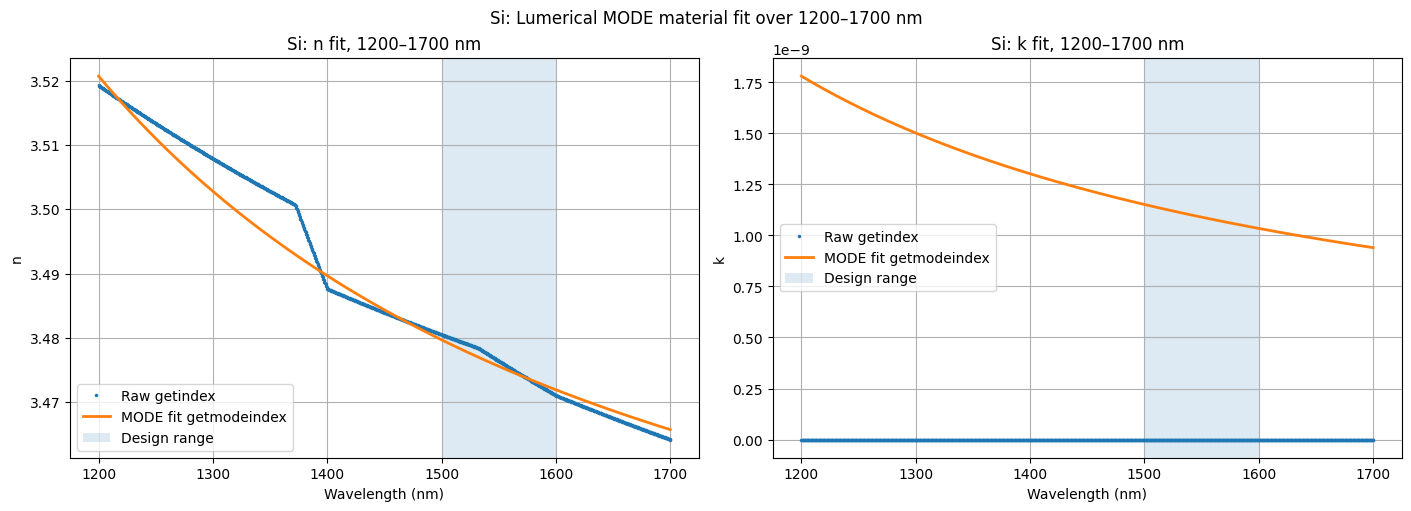

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_MODE_fit_1200_1700nm.png


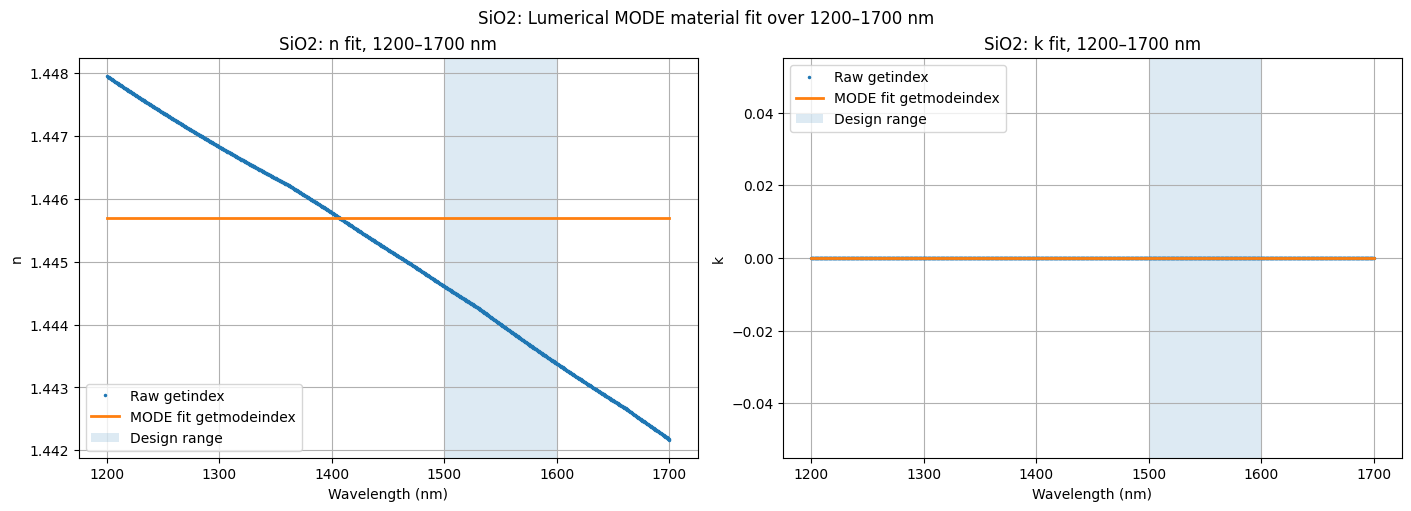

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_MODE_fit_1200_1700nm.png


In [56]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[0].plot(
        d["lambda_fit_nm"],
        d["n_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[0].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[0].set_title(f"{label}: n fit, 1200–1700 nm")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_raw_fit"],
        ".",
        markersize=3,
        label="Raw getindex",
    )

    axs[1].plot(
        d["lambda_fit_nm"],
        d["k_mode_fit"],
        "-",
        linewidth=2,
        label="MODE fit getmodeindex",
    )

    axs[1].axvspan(
        settings["lambda_min_nm"],
        settings["lambda_max_nm"],
        alpha=0.15,
        label="Design range",
    )

    axs[1].set_title(f"{label}: k fit, 1200–1700 nm")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    fig.suptitle(
        f"{label}: Lumerical MODE material fit over 1200–1700 nm"
    )

    plot_path = material_dir / f"{label}_MODE_fit_1200_1700nm.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Plot fitted material only in 1500–1600 nm

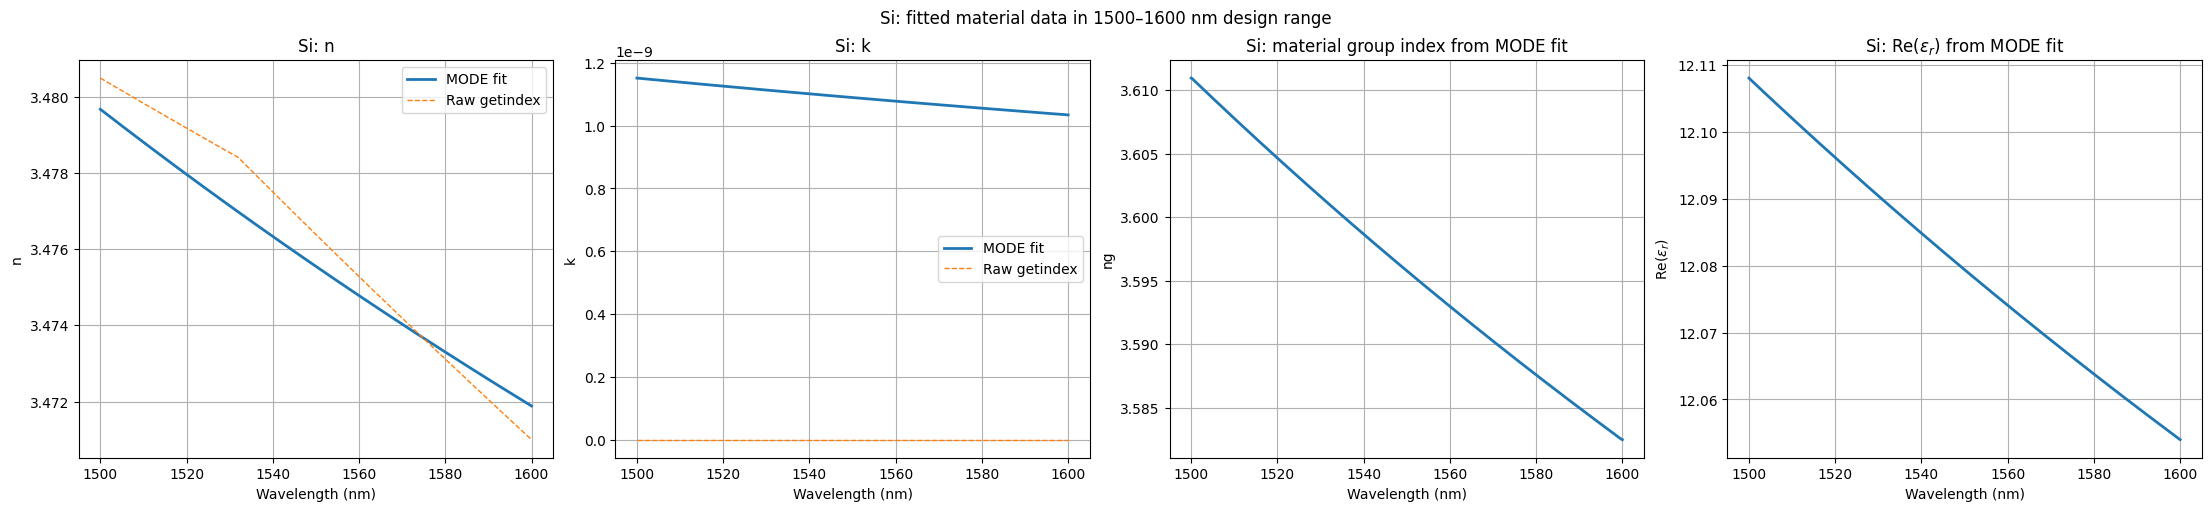

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\Si_MODE_fit_design_range_1500_1600nm.png


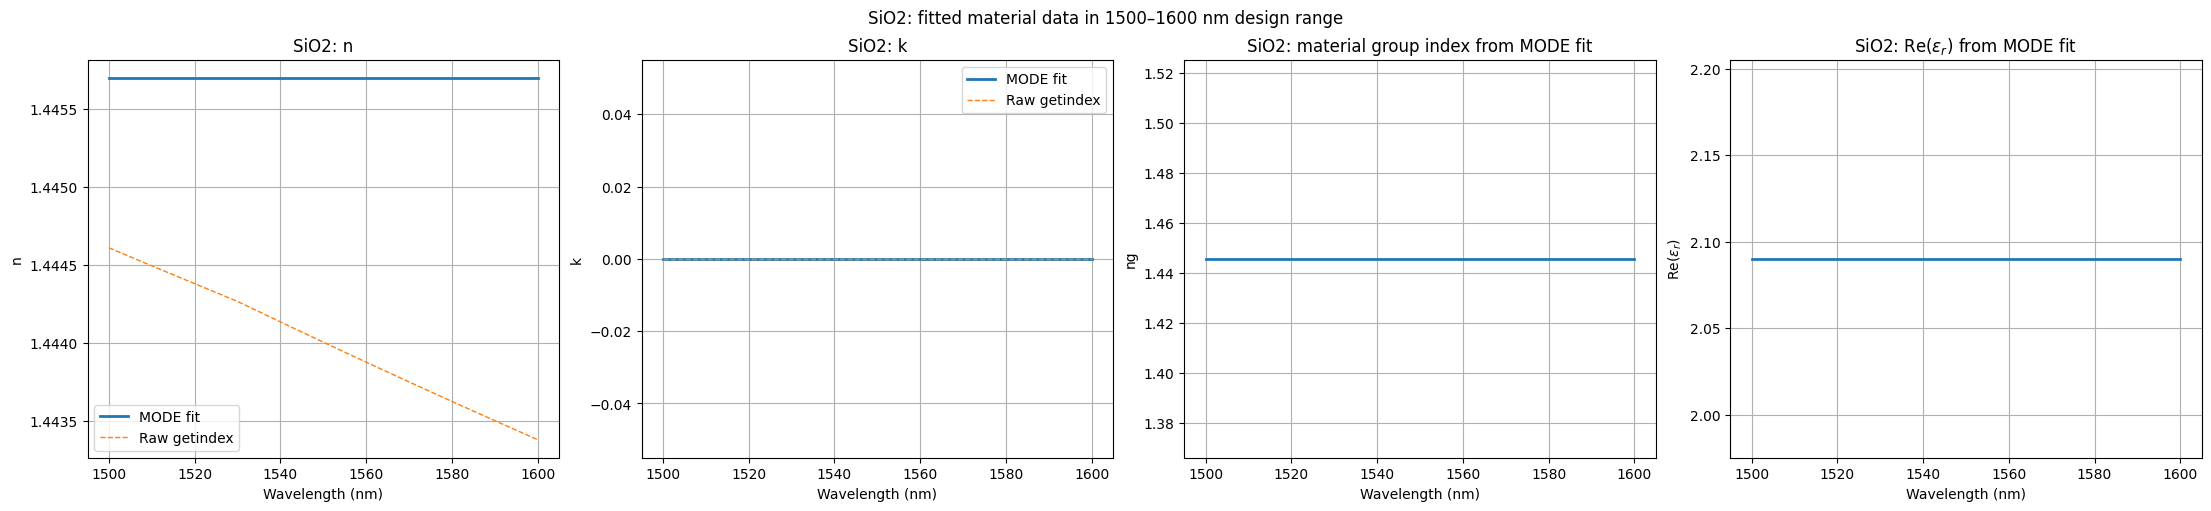

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\material_data\SiO2_MODE_fit_design_range_1500_1600nm.png


In [57]:
for label, d in material_data.items():

    fig, axs = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)

    axs[0].plot(d["lambda_nm"], d["n"], linewidth=2, label="MODE fit")
    axs[0].plot(d["lambda_nm"], d["n_raw"], "--", linewidth=1, label="Raw getindex")
    axs[0].set_title(f"{label}: n")
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("n")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(d["lambda_nm"], d["k"], linewidth=2, label="MODE fit")
    axs[1].plot(d["lambda_nm"], d["k_raw"], "--", linewidth=1, label="Raw getindex")
    axs[1].set_title(f"{label}: k")
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("k")
    axs[1].grid(True)
    axs[1].legend()

    axs[2].plot(d["lambda_nm"], d["ng"], linewidth=2)
    axs[2].set_title(f"{label}: material group index from MODE fit")
    axs[2].set_xlabel("Wavelength (nm)")
    axs[2].set_ylabel("ng")
    axs[2].grid(True)

    axs[3].plot(d["lambda_nm"], d["eps_real"], linewidth=2)
    axs[3].set_title(f"{label}: Re($\\epsilon_r$) from MODE fit")
    axs[3].set_xlabel("Wavelength (nm)")
    axs[3].set_ylabel(r"Re($\epsilon_r$)")
    axs[3].grid(True)

    fig.suptitle(
        f"{label}: fitted material data in 1500–1600 nm design range"
    )

    plot_path = material_dir / f"{label}_MODE_fit_design_range_1500_1600nm.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Print material values at 1550 nm

In [58]:
lambda0_nm = settings["wavelength_um"] * 1000.0

material_at_lambda0 = {}

for label, d in material_data.items():

    n0 = np.interp(lambda0_nm, d["lambda_nm"], d["n"])
    k0 = np.interp(lambda0_nm, d["lambda_nm"], d["k"])
    ng0 = np.interp(lambda0_nm, d["lambda_nm"], d["ng"])
    eps_energy0 = np.interp(lambda0_nm, d["lambda_nm"], d["eps_energy"])

    material_at_lambda0[label] = {
        "n": n0,
        "k": k0,
        "ng": ng0,
        "eps_energy": eps_energy0,
    }

print(f"Material values at lambda = {lambda0_nm:.1f} nm")
print("Values are from MODE multi-coefficient fit over 1200–1700 nm.\n")

for label, d in material_at_lambda0.items():
    print(
        f"{label}: "
        f"n = {d['n']:.8f}, "
        f"k = {d['k']:.3e}, "
        f"ng_material = {d['ng']:.8f}, "
        f"eps_energy = {d['eps_energy']:.8f}"
    )

Material values at lambda = 1550.0 nm
Values are from MODE multi-coefficient fit over 1200–1700 nm.

Si: n = 3.47554455, k = 1.090e-09, ng_material = 3.59578939, eps_energy = 12.91524254
SiO2: n = 1.44569554, k = 0.000e+00, ng_material = 1.44569554, eps_energy = 2.09003561


## Clear layout and add SiO₂ box

In [59]:
mode.switchtolayout()
mode.deleteall()

mode.addrect()
mode.set("name", "SiO2_box")
mode.set("material", settings["sio2_material_name"])

mode.set("x", 0.0)
mode.set("y", 0.0)
mode.set("z", 0.0)

mode.set("x span", settings["oxide_x_span_um"] * um)
mode.set("y span", settings["oxide_y_span_um"] * um)
mode.set("z span", settings["z_span_um"] * um)

print("Added SiO2 simulation box.")

Added SiO2 simulation box.


## Add 220 nm Si waveguide

In [60]:
mode.addrect()
mode.set("name", "Si_waveguide")
mode.set("material", settings["si_material_name"])

mode.set("x", settings["wg_center_x_um"] * um)
mode.set("y", settings["wg_center_y_um"] * um)
mode.set("z", 0.0)

mode.set("x span", settings["wg_width_um"] * um)
mode.set("y span", settings["wg_thickness_um"] * um)
mode.set("z span", settings["z_span_um"] * um)

print("Added silicon waveguide.")
print(f"Width = {settings['wg_width_um']} um")
print(f"Thickness = {settings['wg_thickness_um']} um")

Added silicon waveguide.
Width = 0.3 um
Thickness = 0.22 um


## Add FDE region

In [61]:
mode.addfde()

# Propagation along z, cross-section in x-y
mode.set("solver type", "2D Z normal")

mode.set("x", settings["fde_center_x_um"] * um)
mode.set("y", settings["fde_center_y_um"] * um)

mode.set("x span", settings["fde_x_span_um"] * um)
mode.set("y span", settings["fde_y_span_um"] * um)

mode.set("wavelength", settings["wavelength_um"] * um)

# Boundary conditions
bc = settings["fde_bc"]

mode.set("x min bc", bc)
mode.set("x max bc", bc)
mode.set("y min bc", bc)
mode.set("y max bc", bc)

# Number of modes
mode.set("number of trial modes", settings["number_of_trial_modes"])

# Mesh
mode.set("define x mesh by", "maximum mesh step")
mode.set("define y mesh by", "maximum mesh step")

mode.set("dx", settings["fde_dx_um"] * um)
mode.set("dy", settings["fde_dy_um"] * um)

print("Added FDE region.")
print(f"Boundary condition = {bc}")
print(f"FDE span = {settings['fde_x_span_um']} um x {settings['fde_y_span_um']} um")
print(f"Global dx = {settings['fde_dx_um']} um")
print(f"Global dy = {settings['fde_dy_um']} um")

Added FDE region.
Boundary condition = PML
FDE span = 20.0 um x 20.0 um
Global dx = 0.05 um
Global dy = 0.05 um


## Optional extra mesh

In [62]:
if settings["use_extra_mesh"]:

    mesh_x_span_um = settings["mesh_factor_x"] * settings["wg_width_um"]
    mesh_y_span_um = settings["mesh_factor_y"] * settings["wg_thickness_um"]

    mode.addmesh()
    mode.set("name", settings["extra_mesh_name"])

    mode.set("x", settings["wg_center_x_um"] * um)
    mode.set("y", settings["wg_center_y_um"] * um)
    mode.set("z", 0.0)

    mode.set("x span", mesh_x_span_um * um)
    mode.set("y span", mesh_y_span_um * um)
    mode.set("z span", settings["z_span_um"] * um)

    mode.set("override x mesh", 1)
    mode.set("override y mesh", 1)

    mode.set("dx", settings["local_dx_um"] * um)
    mode.set("dy", settings["local_dy_um"] * um)

    print("Added extra mesh override.")
    print(f"Mesh x span = {mesh_x_span_um:.4f} um")
    print(f"Mesh y span = {mesh_y_span_um:.4f} um")
    print(f"Local dx = {settings['local_dx_um']} um")
    print(f"Local dy = {settings['local_dy_um']} um")

else:
    print("Extra mesh override disabled.")

Added extra mesh override.
Mesh x span = 0.9000 um
Mesh y span = 1.1000 um
Local dx = 0.01 um
Local dy = 0.01 um


## Create run folder and save simulation

In [63]:
project_root = Path.cwd()

simulation_runs_dir = project_root / "simulation_runs"
simulation_runs_dir.mkdir(exist_ok=True)

base_run_name = settings["folder_name"]

existing_run_numbers = []

for item in simulation_runs_dir.iterdir():
    if item.is_dir():
        m = re.fullmatch(rf"{re.escape(base_run_name)}_(\d+)", item.name)
        if m:
            existing_run_numbers.append(int(m.group(1)))

next_run_number = 1 if not existing_run_numbers else max(existing_run_numbers) + 1

run_folder_name = f"{base_run_name}_{next_run_number:02d}"
run_dir = simulation_runs_dir / run_folder_name
run_dir.mkdir(exist_ok=False)

lms_file_path = run_dir / f"{settings['simulation_file_name']}.lms"

mode.save(str(lms_file_path))

print("Created run folder:")
print(run_dir)

print("\nSaved simulation:")
print(lms_file_path)

Created run folder:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02

Saved simulation:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\single_si_wg_fde.lms


## Solve modes

In [64]:
mode.findmodes()

print("FDE mode solve finished.")

FDE mode solve finished.


## Helper functions

In [65]:
def squeeze_arr(a):
    return np.squeeze(np.array(a))


def real_arr(a):
    return np.real(squeeze_arr(a))


def scalar_or_nan(x):
    try:
        x = np.squeeze(np.array(x))
        if x.size == 0:
            return np.nan
        return np.real(x.item())
    except Exception:
        return np.nan


def get_mode_data(mode_obj, mode_number, quantity):
    return squeeze_arr(mode_obj.getdata(f"FDE::data::mode{mode_number}", quantity))


def safe_get_mode_data(mode_obj, mode_number, quantity, default=np.nan):
    try:
        return get_mode_data(mode_obj, mode_number, quantity)
    except Exception:
        return default


def get_from_mode_or_list(mode_obj, mode_number, key, default=np.nan):
    try:
        return mode_obj.getdata(f"FDE::data::mode{mode_number}", key)
    except Exception:
        pass

    try:
        return mode_obj.getdata("FDE::data", key)[mode_number - 1]
    except Exception:
        return default


def get_index_map_from_material(mode_obj):
    try:
        n = mode_obj.getdata("FDE::data::material", "index")
        return np.squeeze(np.real(np.array(n)))
    except Exception:
        pass

    try:
        nx = mode_obj.getdata("FDE::data::material", "index_x")
        return np.squeeze(np.real(np.array(nx)))
    except Exception:
        pass

    raise RuntimeError("Could not find index data in FDE::data::material.")


def trapz2(f, x, y):
    return np.trapz(np.trapz(f, y, axis=1), x, axis=0)


def positive_weight(F):
    F = np.real(F)
    return np.maximum(F, 0)


def nearest_index(arr, value):
    return int(np.argmin(np.abs(arr - value)))


def apply_window(x, y, data, x_window=None, y_window=None):
    x_mask = np.ones_like(x, dtype=bool)
    y_mask = np.ones_like(y, dtype=bool)

    if x_window is not None:
        x_mask = (x >= x_window[0]) & (x <= x_window[1])

    if y_window is not None:
        y_mask = (y >= y_window[0]) & (y <= y_window[1])

    return x[x_mask], y[y_mask], data[np.ix_(x_mask, y_mask)]

## Extract mode table

In [66]:
num_modes = int(settings["number_of_trial_modes"])

mode_rows = []

for m in range(1, num_modes + 1):

    neff = get_from_mode_or_list(mode, m, "neff")

    if np.all(pd.isna(neff)):
        continue

    loss = get_from_mode_or_list(mode, m, "loss")
    ng = get_from_mode_or_list(mode, m, "ng")

    te_pol = get_from_mode_or_list(mode, m, "TE polarization fraction")
    wg_te_fraction = get_from_mode_or_list(mode, m, "waveguide TE fraction")
    wg_te_tm = get_from_mode_or_list(mode, m, "waveguide TE/TM fraction")

    eff_area = get_from_mode_or_list(mode, m, "effective area")

    try:
        eff_area_um2 = scalar_or_nan(eff_area) * 1e12
    except Exception:
        eff_area_um2 = np.nan

    mode_rows.append({
        "mode_number": m,
        "neff": complex(np.squeeze(neff)),
        "neff_real": np.real(np.squeeze(neff)),
        "neff_imag": np.imag(np.squeeze(neff)),
        "loss_dB_per_cm": scalar_or_nan(loss),
        "group_index": complex(np.squeeze(ng)) if not np.all(pd.isna(ng)) else np.nan,
        "group_index_real": np.real(np.squeeze(ng)) if not np.all(pd.isna(ng)) else np.nan,
        "TE_polarization_fraction": scalar_or_nan(te_pol),
        "waveguide_TE_fraction": scalar_or_nan(wg_te_fraction),
        "waveguide_TE_TM_fraction": scalar_or_nan(wg_te_tm),
        "lumerical_effective_area_um2": eff_area_um2,
    })

modes_df = pd.DataFrame(mode_rows)

results_dir = Path(lms_file_path).parent

mode_summary_path = results_dir / "modes_raw_summary.csv"
modes_df.to_csv(mode_summary_path, index=False)

print("Saved raw mode summary:")
print(mode_summary_path)

modes_df

Saved raw mode summary:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\modes_raw_summary.csv


,mode_number,neff,neff_real,neff_imag,loss_dB_per_cm,group_index,group_index_real,TE_polarization_fraction,waveguide_TE_fraction,waveguide_TE_TM_fraction,lumerical_effective_area_um2
0,1,1.827319-0.000000j,1.8273190909042705,-4.941178550642371e-18,-1.739775e-10,4.141294-0.000000j,4.141293639319163,0.940742,NaN,NaN,NaN
1,2,1.593650+0.000000j,1.5936495672871278,1.6569864689472062e-16,5.834202e-09,2.891497+0.000000j,2.891497108273125,0.044153,NaN,NaN,NaN


## Mode metric functions

In [67]:
def calc_mode_metrics_from_weight(x, y, F):
    F = positive_weight(F)

    total = trapz2(F, x, y)

    if total <= 0 or not np.isfinite(total):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    X, Y = np.meshgrid(x, y, indexing="ij")

    xbar = trapz2(F * X, x, y) / total
    ybar = trapz2(F * Y, x, y) / total

    sigma_x = np.sqrt(trapz2(F * (X - xbar)**2, x, y) / total)
    sigma_y = np.sqrt(trapz2(F * (Y - ybar)**2, x, y) / total)

    MFD_x = 4 * sigma_x
    MFD_y = 4 * sigma_y

    denom = trapz2(F**2, x, y)

    if denom <= 0 or not np.isfinite(denom):
        area = np.nan
    else:
        area = total**2 / denom

    return area, xbar, ybar, MFD_x, MFD_y


def build_eps_energy_map_from_index(n_plot):
    n_si = material_at_lambda0["Si"]["n"]
    n_sio2 = material_at_lambda0["SiO2"]["n"]

    eps_energy_si = material_at_lambda0["Si"]["eps_energy"]
    eps_energy_sio2 = material_at_lambda0["SiO2"]["eps_energy"]

    dist_si = np.abs(n_plot - n_si)
    dist_sio2 = np.abs(n_plot - n_sio2)

    eps_energy_map = np.where(dist_si < dist_sio2, eps_energy_si, eps_energy_sio2)

    return eps_energy_map


def select_area_weight(area_definition, Sz, W, E2):
    area_definition = area_definition.strip().upper()

    if area_definition == "W":
        return W, "W", "dispersive energy density W"
    elif area_definition == "SZ":
        return Sz, "Sz", r"$S_z$"
    elif area_definition == "E2":
        return E2, "E2", r"$|E|^2$"
    else:
        raise ValueError("Use one of: E2, Sz, W.")

## Plot helper for index map

In [68]:
from matplotlib.colors import BoundaryNorm

def plot_discrete_index(ax, x, y, n_data, cmap="jet"):
    vals = np.unique(np.round(n_data[np.isfinite(n_data)], 6))
    vals = np.sort(vals)

    if len(vals) == 1:
        bounds = [vals[0] - 0.01, vals[0] + 0.01]
    else:
        mids = 0.5 * (vals[:-1] + vals[1:])
        bounds = np.r_[
            vals[0] - (mids[0] - vals[0]),
            mids,
            vals[-1] + (vals[-1] - mids[-1]),
        ]

    norm = BoundaryNorm(bounds, plt.get_cmap(cmap).N)

    im = ax.pcolormesh(
        x,
        y,
        n_data.T,
        shading="auto",
        cmap=cmap,
        norm=norm,
    )

    cbar = plt.colorbar(im, ax=ax, ticks=vals)
    cbar.set_label("Refractive index")

    return im, cbar

## Extract fields and calculated metrics

In [69]:
plot_settings = {
    "cmap": settings["cmap"],
    "x_window": settings["plot_window_x_um"],
    "y_window": settings["plot_window_y_um"],
    "cut_x_um": settings["field_cut_x_um"],
    "cut_y_um": settings["field_cut_y_um"],
    "area_definition_for_metrics": settings["area_definition_for_metrics"],
}

derived_rows = []

for m in modes_df["mode_number"].astype(int):

    print(f"\nProcessing mode {m}...")

    x = real_arr(get_mode_data(mode, m, "x")) / um
    y = real_arr(get_mode_data(mode, m, "y")) / um

    Ex = np.squeeze(get_mode_data(mode, m, "Ex"))
    Ey = np.squeeze(get_mode_data(mode, m, "Ey"))
    Ez = np.squeeze(get_mode_data(mode, m, "Ez"))

    Hx = np.squeeze(get_mode_data(mode, m, "Hx"))
    Hy = np.squeeze(get_mode_data(mode, m, "Hy"))
    Hz = np.squeeze(get_mode_data(mode, m, "Hz"))

    n = np.squeeze(get_index_map_from_material(mode))

    if n.ndim == 3:
        n_plot = n[:, :, 0]
    elif n.ndim == 2:
        n_plot = n
    else:
        raise ValueError(f"Unexpected index map shape: {n.shape}")

    Sz = 0.5 * np.real(Ex * np.conj(Hy) - Ey * np.conj(Hx))

    E2 = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    H2 = np.abs(Hx)**2 + np.abs(Hy)**2 + np.abs(Hz)**2

    eps_energy_map = build_eps_energy_map_from_index(n_plot)

    W = 0.25 * (eps0 * eps_energy_map * E2 + mu0 * H2)

    area_E2, xbar_E2, ybar_E2, MFD_E2_x, MFD_E2_y = calc_mode_metrics_from_weight(x, y, E2)
    area_Sz, xbar_Sz, ybar_Sz, MFD_Sz_x, MFD_Sz_y = calc_mode_metrics_from_weight(x, y, Sz)
    area_W, xbar_W, ybar_W, MFD_W_x, MFD_W_y = calc_mode_metrics_from_weight(x, y, W)

    metric_weight, metric_key, metric_label = select_area_weight(
        plot_settings["area_definition_for_metrics"],
        Sz,
        W,
        E2,
    )

    selected_area, selected_xbar, selected_ybar, selected_MFD_x, selected_MFD_y = (
        calc_mode_metrics_from_weight(x, y, metric_weight)
    )

    derived_rows.append({
        "mode_number": m,

        "selected_area_definition": metric_key,
        "selected_mode_area_um2": selected_area,
        "selected_xbar_um": selected_xbar,
        "selected_ybar_um": selected_ybar,
        "selected_MFD_x_um": selected_MFD_x,
        "selected_MFD_y_um": selected_MFD_y,

        "mode_area_E2_um2": area_E2,
        "xbar_E2_um": xbar_E2,
        "ybar_E2_um": ybar_E2,
        "MFD_E2_x_um": MFD_E2_x,
        "MFD_E2_y_um": MFD_E2_y,

        "mode_area_Sz_um2": area_Sz,
        "xbar_Sz_um": xbar_Sz,
        "ybar_Sz_um": ybar_Sz,
        "MFD_Sz_x_um": MFD_Sz_x,
        "MFD_Sz_y_um": MFD_Sz_y,

        "mode_area_W_um2": area_W,
        "xbar_W_um": xbar_W,
        "ybar_W_um": ybar_W,
        "MFD_W_x_um": MFD_W_x,
        "MFD_W_y_um": MFD_W_y,
    })

    X, Y = np.meshgrid(x, y, indexing="ij")

    field_df = pd.DataFrame({
        "x_um": X.ravel(),
        "y_um": Y.ravel(),

        "Ex_real": np.real(Ex).ravel(),
        "Ex_imag": np.imag(Ex).ravel(),
        "Ey_real": np.real(Ey).ravel(),
        "Ey_imag": np.imag(Ey).ravel(),
        "Ez_real": np.real(Ez).ravel(),
        "Ez_imag": np.imag(Ez).ravel(),

        "Hx_real": np.real(Hx).ravel(),
        "Hx_imag": np.imag(Hx).ravel(),
        "Hy_real": np.real(Hy).ravel(),
        "Hy_imag": np.imag(Hy).ravel(),
        "Hz_real": np.real(Hz).ravel(),
        "Hz_imag": np.imag(Hz).ravel(),

        "E2_abs": E2.ravel(),
        "H2_abs": H2.ravel(),
        "Sz_real": Sz.ravel(),
        "W_dispersive": W.ravel(),
        "metric_weight_used_for_MFD": metric_weight.ravel(),
        "index": n_plot.ravel(),
        "eps_energy_map": eps_energy_map.ravel(),
    })

    field_csv_path = results_dir / f"mode_{m}_fields.csv"
    field_df.to_csv(field_csv_path, index=False)

    print("Saved field CSV:", field_csv_path)

derived_df = pd.DataFrame(derived_rows)

derived_df


Processing mode 1...
Saved field CSV: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_1_fields.csv

Processing mode 2...
Saved field CSV: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_2_fields.csv


,mode_number,selected_area_definition,selected_mode_area_um2,selected_xbar_um,selected_ybar_um,selected_MFD_x_um,selected_MFD_y_um,mode_area_E2_um2,xbar_E2_um,ybar_E2_um,...,mode_area_Sz_um2,xbar_Sz_um,ybar_Sz_um,MFD_Sz_x_um,MFD_Sz_y_um,mode_area_W_um2,xbar_W_um,ybar_W_um,MFD_W_x_um,MFD_W_y_um
0,1,E2,0.262251,1.990568e-16,9.328256e-16,0.822275,0.558724,0.262251,1.990568e-16,9.328256e-16,...,0.155525,7.235420e-17,1.233739e-15,0.599352,0.595197,0.135948,2.890353e-16,7.104575e-16,0.514908,0.486878
1,2,E2,0.413782,9.853694e-16,3.106009e-16,0.873899,1.081815,0.413782,9.853694e-16,3.106009e-16,...,0.474768,1.232544e-15,1.496340e-17,0.974226,0.998482,0.249511,9.655086e-16,2.133094e-16,0.797984,0.793390


## Plot E/H fields

Plotting E/H fields for mode 1...


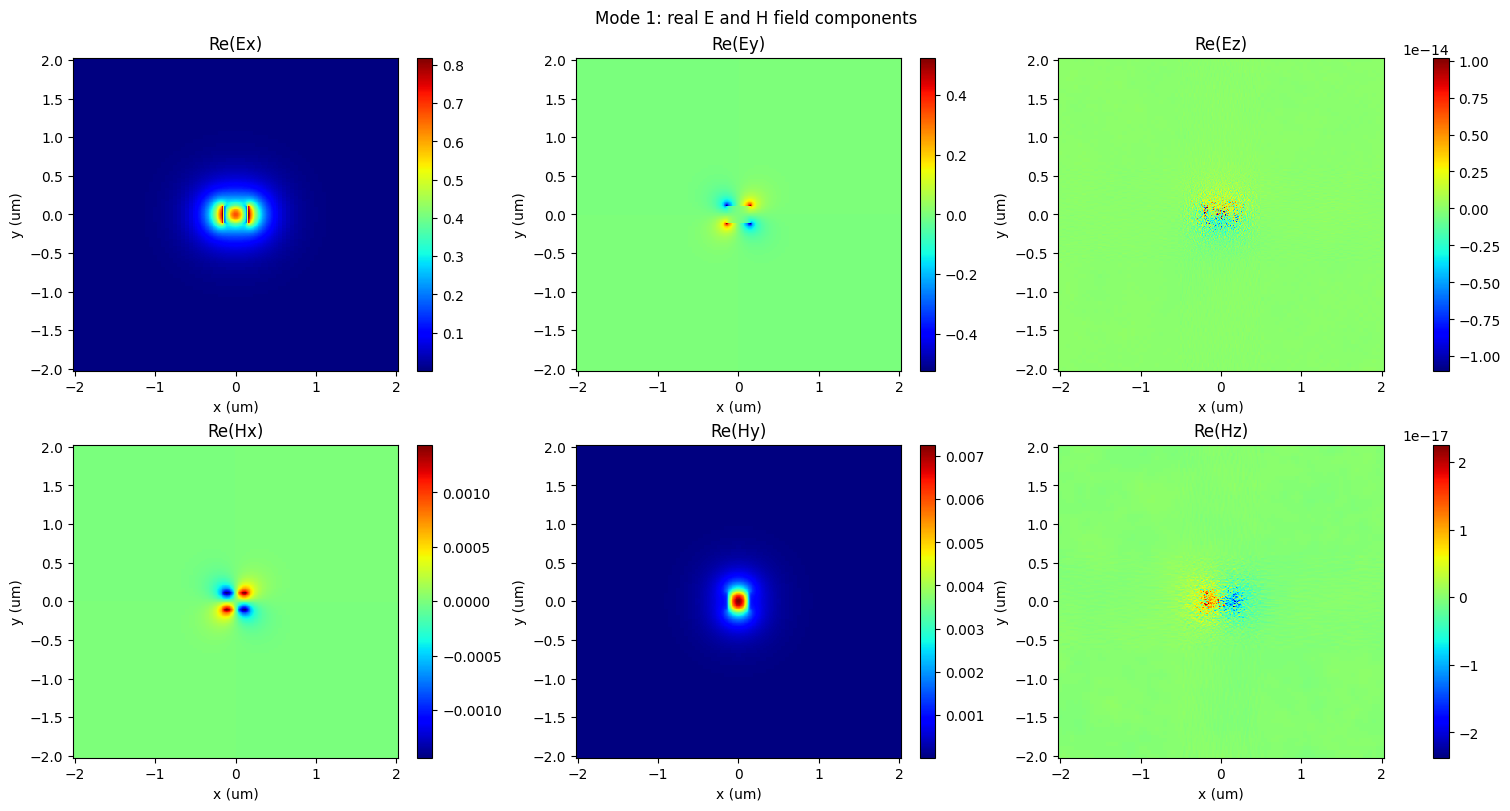

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_1_EH_fields.png
Plotting E/H fields for mode 2...


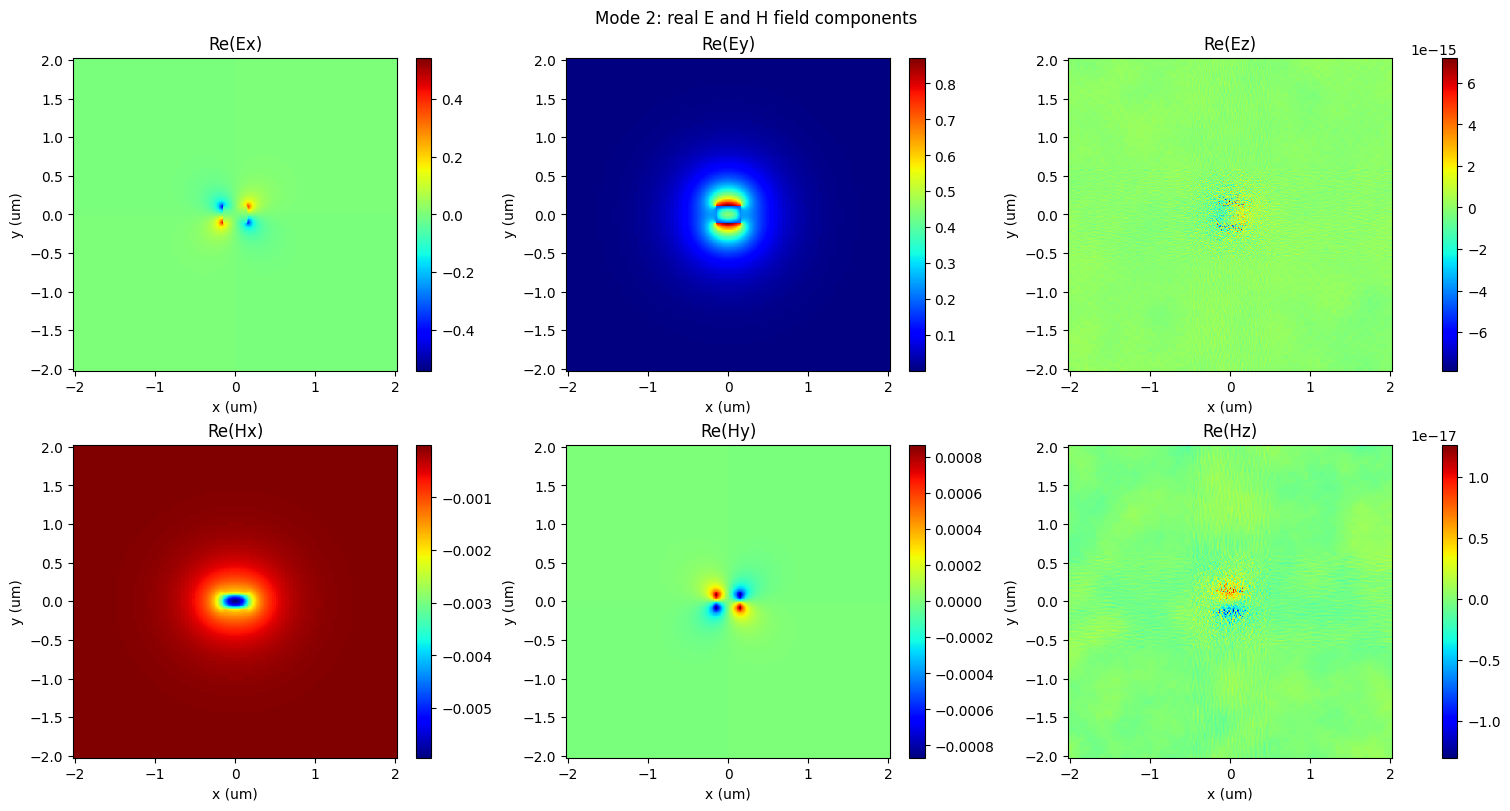

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_2_EH_fields.png


In [70]:
for m in modes_df["mode_number"].astype(int):

    print(f"Plotting E/H fields for mode {m}...")

    x = real_arr(get_mode_data(mode, m, "x")) / um
    y = real_arr(get_mode_data(mode, m, "y")) / um

    Ex = np.squeeze(get_mode_data(mode, m, "Ex"))
    Ey = np.squeeze(get_mode_data(mode, m, "Ey"))
    Ez = np.squeeze(get_mode_data(mode, m, "Ez"))

    Hx = np.squeeze(get_mode_data(mode, m, "Hx"))
    Hy = np.squeeze(get_mode_data(mode, m, "Hy"))
    Hz = np.squeeze(get_mode_data(mode, m, "Hz"))

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

    field_items = [
        (np.real(Ex), "Re(Ex)"),
        (np.real(Ey), "Re(Ey)"),
        (np.real(Ez), "Re(Ez)"),
        (np.real(Hx), "Re(Hx)"),
        (np.real(Hy), "Re(Hy)"),
        (np.real(Hz), "Re(Hz)"),
    ]

    for ax, (data, title) in zip(axs.ravel(), field_items):
        x_plot, y_plot, data_plot = apply_window(
            x,
            y,
            data,
            plot_settings["x_window"],
            plot_settings["y_window"],
        )

        im = ax.pcolormesh(
            x_plot,
            y_plot,
            data_plot.T,
            shading="auto",
            cmap=plot_settings["cmap"],
        )

        ax.set_title(title)
        ax.set_xlabel("x (um)")
        ax.set_ylabel("y (um)")
        fig.colorbar(im, ax=ax)

    fig.suptitle(f"Mode {m}: real E and H field components")

    plot_path = results_dir / f"mode_{m}_EH_fields.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Plot index, Sz, W, and |E|²

Plotting index/Sz/W/E2 for mode 1...


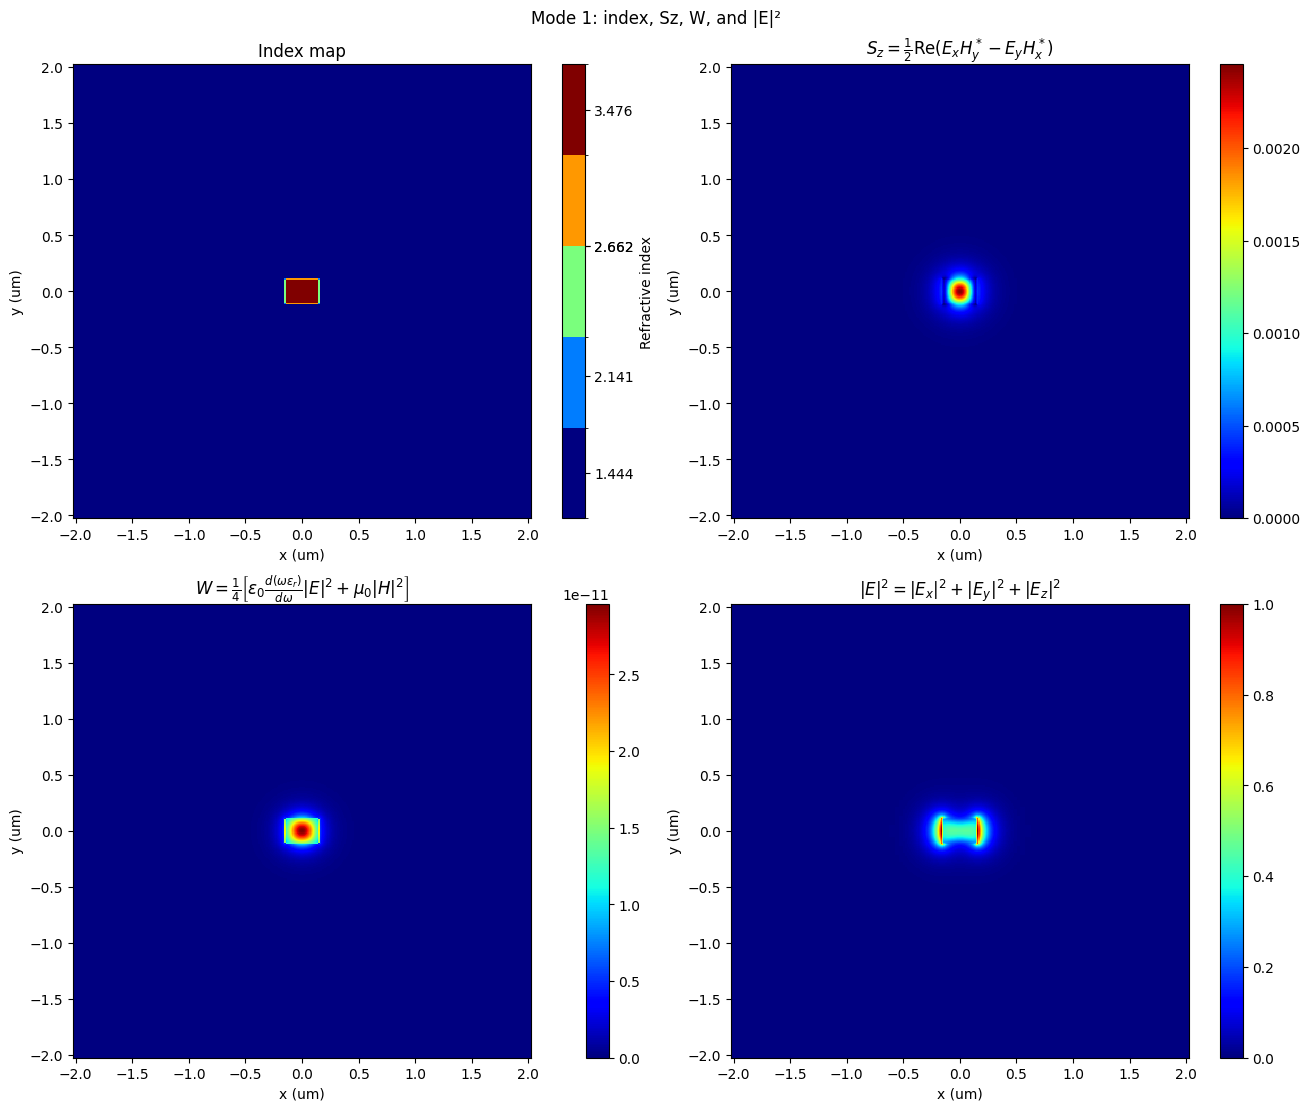

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_1_index_Sz_W_E2.png
Plotting index/Sz/W/E2 for mode 2...


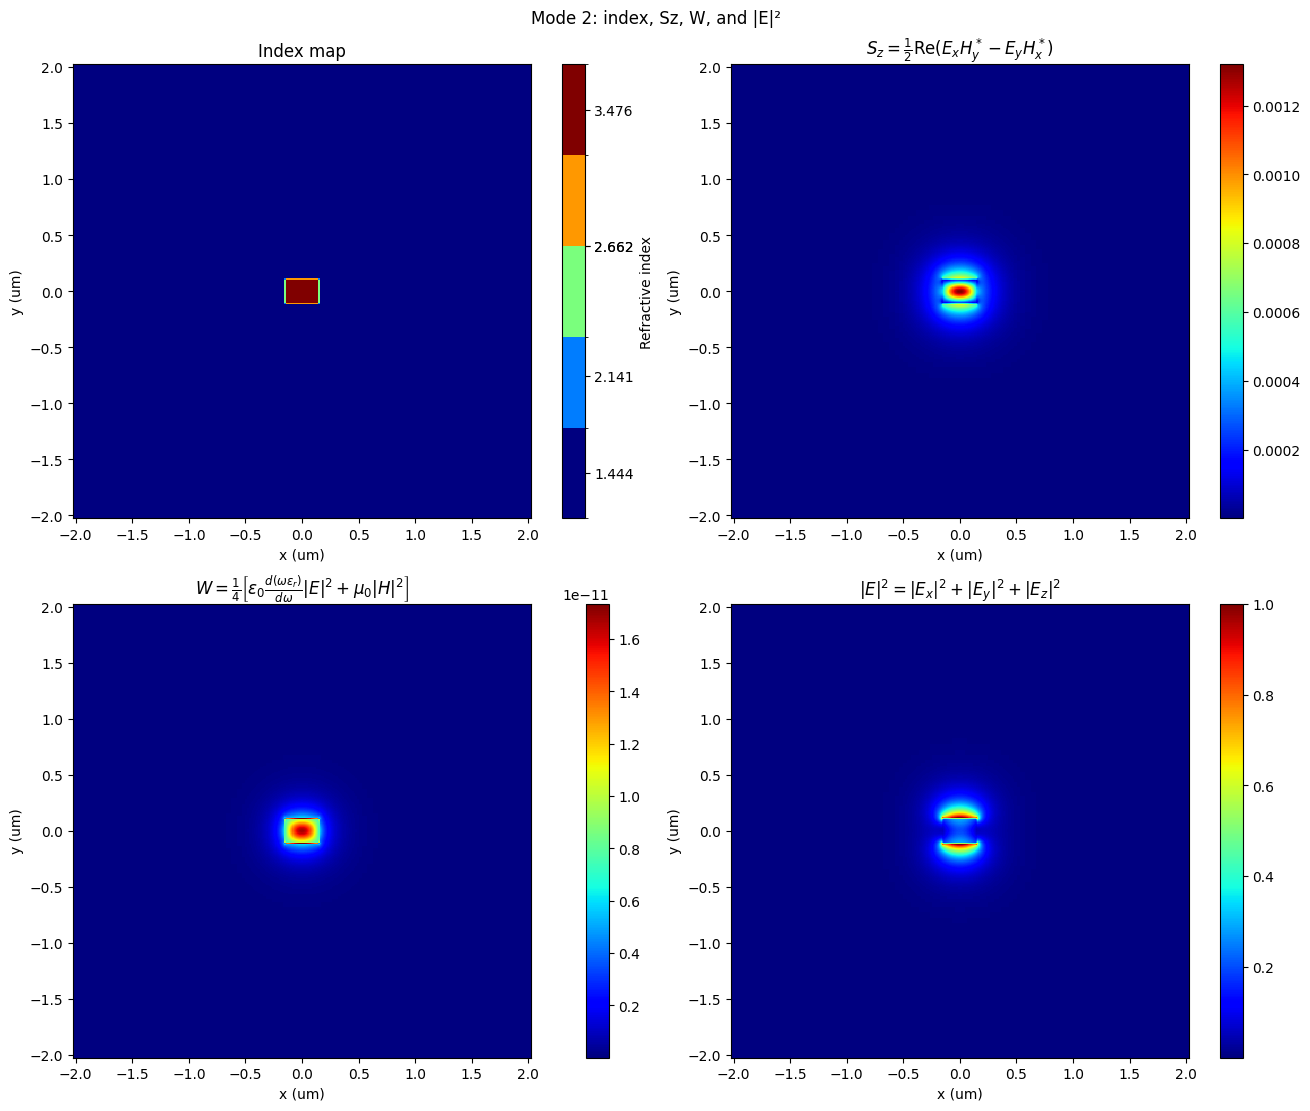

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_2_index_Sz_W_E2.png


In [71]:
for m in modes_df["mode_number"].astype(int):

    print(f"Plotting index/Sz/W/E2 for mode {m}...")

    x = real_arr(get_mode_data(mode, m, "x")) / um
    y = real_arr(get_mode_data(mode, m, "y")) / um

    Ex = np.squeeze(get_mode_data(mode, m, "Ex"))
    Ey = np.squeeze(get_mode_data(mode, m, "Ey"))
    Ez = np.squeeze(get_mode_data(mode, m, "Ez"))

    Hx = np.squeeze(get_mode_data(mode, m, "Hx"))
    Hy = np.squeeze(get_mode_data(mode, m, "Hy"))
    Hz = np.squeeze(get_mode_data(mode, m, "Hz"))

    n = np.squeeze(get_index_map_from_material(mode))

    if n.ndim == 3:
        n_plot = n[:, :, 0]
    elif n.ndim == 2:
        n_plot = n
    else:
        raise ValueError(f"Unexpected index map shape: {n.shape}")

    Sz = 0.5 * np.real(Ex * np.conj(Hy) - Ey * np.conj(Hx))

    E2 = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    H2 = np.abs(Hx)**2 + np.abs(Hy)**2 + np.abs(Hz)**2

    eps_energy_map = build_eps_energy_map_from_index(n_plot)
    W = 0.25 * (eps0 * eps_energy_map * E2 + mu0 * H2)

    fig, axs = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)

    x_plot, y_plot, n_win = apply_window(
        x,
        y,
        n_plot,
        plot_settings["x_window"],
        plot_settings["y_window"],
    )

    plot_discrete_index(
        axs[0, 0],
        x_plot,
        y_plot,
        n_win,
        cmap=plot_settings["cmap"],
    )

    axs[0, 0].set_title("Index map")
    axs[0, 0].set_xlabel("x (um)")
    axs[0, 0].set_ylabel("y (um)")

    x_plot, y_plot, Sz_win = apply_window(
        x,
        y,
        Sz,
        plot_settings["x_window"],
        plot_settings["y_window"],
    )

    im = axs[0, 1].pcolormesh(
        x_plot,
        y_plot,
        Sz_win.T,
        shading="auto",
        cmap=plot_settings["cmap"],
    )

    axs[0, 1].set_title(r"$S_z = \frac{1}{2}\mathrm{Re}(E_xH_y^* - E_yH_x^*)$")
    axs[0, 1].set_xlabel("x (um)")
    axs[0, 1].set_ylabel("y (um)")
    fig.colorbar(im, ax=axs[0, 1])

    x_plot, y_plot, W_win = apply_window(
        x,
        y,
        W,
        plot_settings["x_window"],
        plot_settings["y_window"],
    )

    im = axs[1, 0].pcolormesh(
        x_plot,
        y_plot,
        W_win.T,
        shading="auto",
        cmap=plot_settings["cmap"],
    )

    axs[1, 0].set_title(
        r"$W=\frac{1}{4}\left[\epsilon_0\frac{d(\omega\epsilon_r)}{d\omega}|E|^2+\mu_0|H|^2\right]$"
    )
    axs[1, 0].set_xlabel("x (um)")
    axs[1, 0].set_ylabel("y (um)")
    fig.colorbar(im, ax=axs[1, 0])

    x_plot, y_plot, E2_win = apply_window(
        x,
        y,
        E2,
        plot_settings["x_window"],
        plot_settings["y_window"],
    )

    im = axs[1, 1].pcolormesh(
        x_plot,
        y_plot,
        E2_win.T,
        shading="auto",
        cmap=plot_settings["cmap"],
    )

    axs[1, 1].set_title(r"$|E|^2 = |E_x|^2+|E_y|^2+|E_z|^2$")
    axs[1, 1].set_xlabel("x (um)")
    axs[1, 1].set_ylabel("y (um)")
    fig.colorbar(im, ax=axs[1, 1])

    fig.suptitle(f"Mode {m}: index, Sz, W, and |E|²")

    plot_path = results_dir / f"mode_{m}_index_Sz_W_E2.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Plot MFD box and cuts

Plotting selected MFD metric for mode 1...


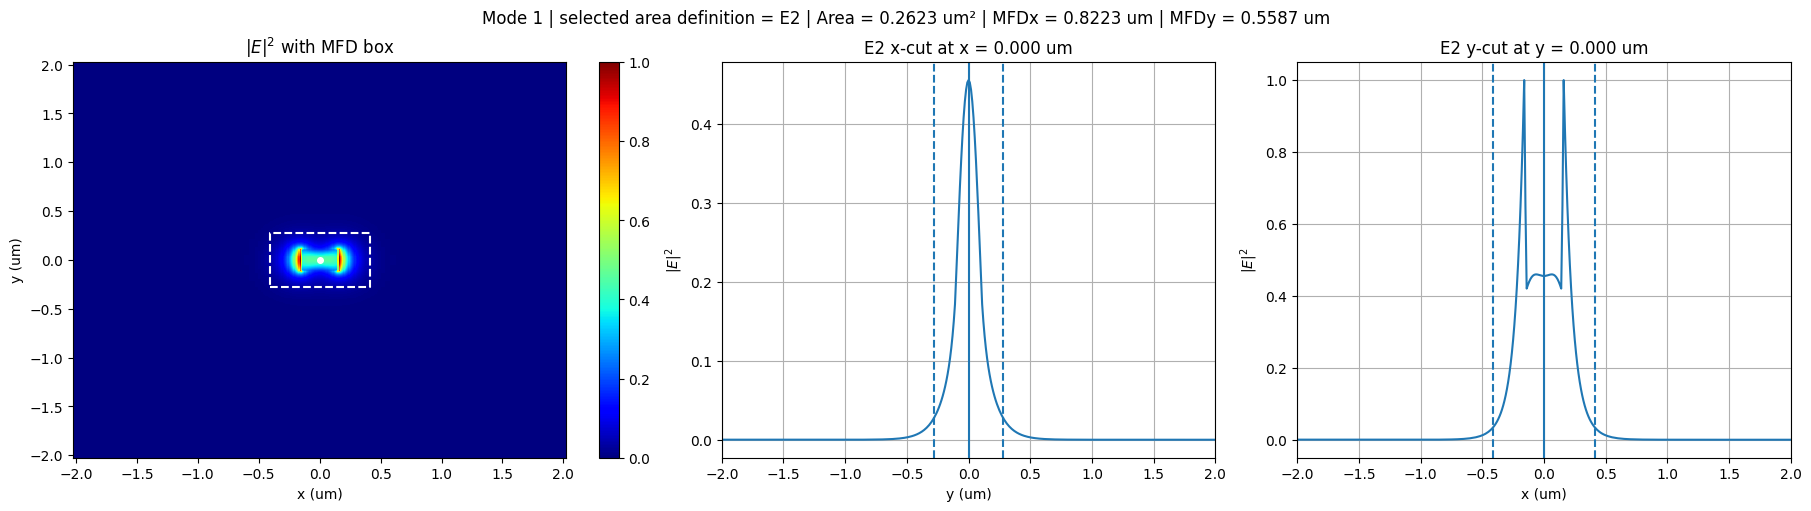

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_1_selected_E2_MFD_and_cuts.png
Plotting selected MFD metric for mode 2...


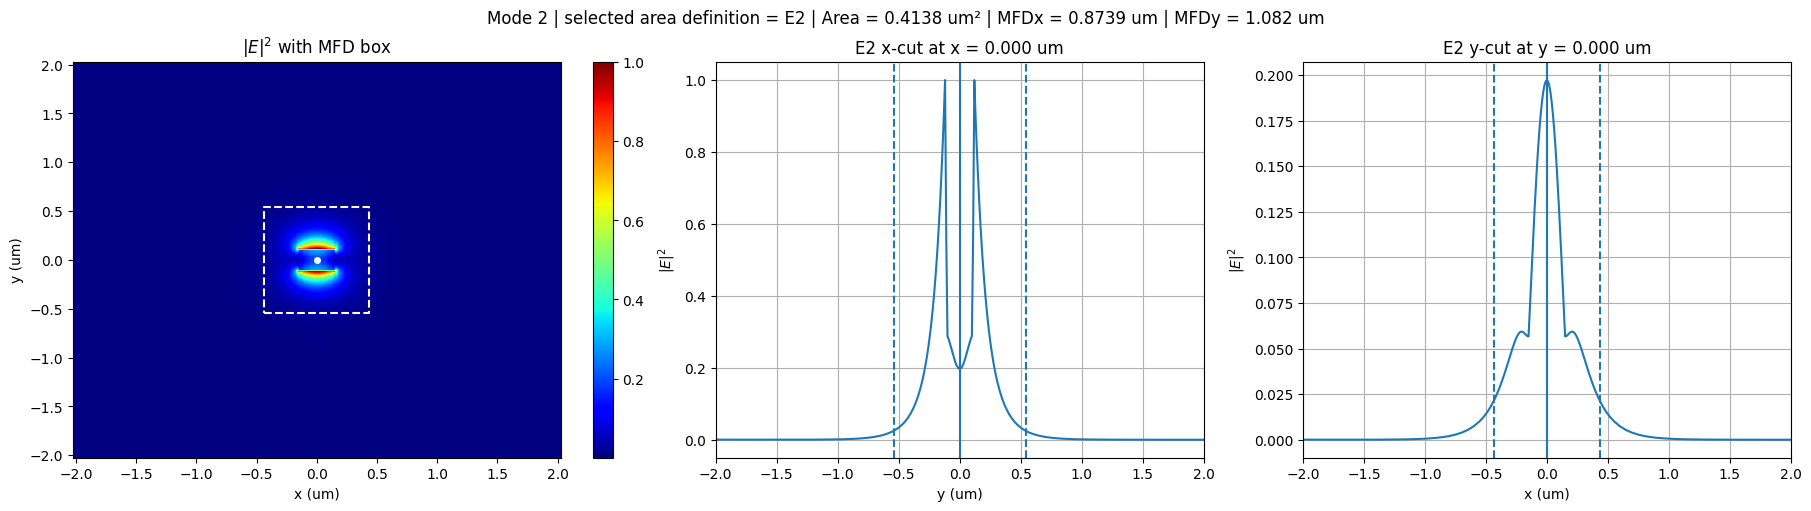

Saved: c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\mode_2_selected_E2_MFD_and_cuts.png


In [72]:
for _, row in derived_df.iterrows():

    m = int(row["mode_number"])

    print(f"Plotting selected MFD metric for mode {m}...")

    x = real_arr(get_mode_data(mode, m, "x")) / um
    y = real_arr(get_mode_data(mode, m, "y")) / um

    Ex = np.squeeze(get_mode_data(mode, m, "Ex"))
    Ey = np.squeeze(get_mode_data(mode, m, "Ey"))
    Ez = np.squeeze(get_mode_data(mode, m, "Ez"))

    Hx = np.squeeze(get_mode_data(mode, m, "Hx"))
    Hy = np.squeeze(get_mode_data(mode, m, "Hy"))
    Hz = np.squeeze(get_mode_data(mode, m, "Hz"))

    n = np.squeeze(get_index_map_from_material(mode))

    if n.ndim == 3:
        n_plot = n[:, :, 0]
    elif n.ndim == 2:
        n_plot = n
    else:
        raise ValueError(f"Unexpected index map shape: {n.shape}")

    Sz = 0.5 * np.real(Ex * np.conj(Hy) - Ey * np.conj(Hx))

    E2 = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    H2 = np.abs(Hx)**2 + np.abs(Hy)**2 + np.abs(Hz)**2

    eps_energy_map = build_eps_energy_map_from_index(n_plot)
    W = 0.25 * (eps0 * eps_energy_map * E2 + mu0 * H2)

    metric_weight, metric_key, metric_label = select_area_weight(
        plot_settings["area_definition_for_metrics"],
        Sz,
        W,
        E2,
    )

    selected_area = row["selected_mode_area_um2"]
    xbar = row["selected_xbar_um"]
    ybar = row["selected_ybar_um"]
    MFD_x = row["selected_MFD_x_um"]
    MFD_y = row["selected_MFD_y_um"]

    x_left = xbar - MFD_x / 2
    x_right = xbar + MFD_x / 2
    y_bottom = ybar - MFD_y / 2
    y_top = ybar + MFD_y / 2

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    x_plot, y_plot, metric_win = apply_window(
        x,
        y,
        metric_weight,
        plot_settings["x_window"],
        plot_settings["y_window"],
    )

    im = axs[0].pcolormesh(
        x_plot,
        y_plot,
        metric_win.T,
        shading="auto",
        cmap=plot_settings["cmap"],
    )

    axs[0].plot(
        [x_left, x_right, x_right, x_left, x_left],
        [y_bottom, y_bottom, y_top, y_top, y_bottom],
        "w--",
        linewidth=1.5,
    )

    axs[0].plot(xbar, ybar, "wo", markersize=4)

    axs[0].set_title(f"{metric_label} with MFD box")
    axs[0].set_xlabel("x (um)")
    axs[0].set_ylabel("y (um)")
    fig.colorbar(im, ax=axs[0])

    ix_cut = nearest_index(x, plot_settings["cut_x_um"])
    x_cut_actual = x[ix_cut]
    metric_xcut = metric_weight[ix_cut, :]

    axs[1].plot(y, metric_xcut)
    axs[1].axvline(y_bottom, linestyle="--")
    axs[1].axvline(y_top, linestyle="--")
    axs[1].axvline(ybar, linestyle="-")
    axs[1].set_title(f"{metric_key} x-cut at x = {x_cut_actual:.3f} um")
    axs[1].set_xlabel("y (um)")
    axs[1].set_ylabel(metric_label)
    axs[1].grid(True)

    if plot_settings["y_window"] is not None:
        axs[1].set_xlim(plot_settings["y_window"])

    iy_cut = nearest_index(y, plot_settings["cut_y_um"])
    y_cut_actual = y[iy_cut]
    metric_ycut = metric_weight[:, iy_cut]

    axs[2].plot(x, metric_ycut)
    axs[2].axvline(x_left, linestyle="--")
    axs[2].axvline(x_right, linestyle="--")
    axs[2].axvline(xbar, linestyle="-")
    axs[2].set_title(f"{metric_key} y-cut at y = {y_cut_actual:.3f} um")
    axs[2].set_xlabel("x (um)")
    axs[2].set_ylabel(metric_label)
    axs[2].grid(True)

    if plot_settings["x_window"] is not None:
        axs[2].set_xlim(plot_settings["x_window"])

    fig.suptitle(
        f"Mode {m} | selected area definition = {metric_key} | "
        f"Area = {selected_area:.4g} um² | "
        f"MFDx = {MFD_x:.4g} um | "
        f"MFDy = {MFD_y:.4g} um"
    )

    plot_path = results_dir / f"mode_{m}_selected_{metric_key}_MFD_and_cuts.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()

    print("Saved:", plot_path)

## Merge and save final summary

In [73]:
final_modes_df = modes_df.merge(derived_df, on="mode_number", how="left")

final_csv_path = results_dir / "modes_summary_with_fields_metrics.csv"
final_modes_df.to_csv(final_csv_path, index=False)

print("Saved final mode summary:")
print(final_csv_path)

final_modes_df

Saved final mode summary:
c:\Users\Amirali\Desktop\Beam_Splitter_Project\lumerical_simulations\Single Waveguide Mode\simulation_runs\single_wg_mode_02\modes_summary_with_fields_metrics.csv


,mode_number,neff,neff_real,neff_imag,loss_dB_per_cm,group_index,group_index_real,TE_polarization_fraction,waveguide_TE_fraction,waveguide_TE_TM_fraction,...,mode_area_Sz_um2,xbar_Sz_um,ybar_Sz_um,MFD_Sz_x_um,MFD_Sz_y_um,mode_area_W_um2,xbar_W_um,ybar_W_um,MFD_W_x_um,MFD_W_y_um
0,1,1.827319-0.000000j,1.8273190909042705,-4.941178550642371e-18,-1.739775e-10,4.141294-0.000000j,4.141293639319163,0.940742,NaN,NaN,...,0.155525,7.235420e-17,1.233739e-15,0.599352,0.595197,0.135948,2.890353e-16,7.104575e-16,0.514908,0.486878
1,2,1.593650+0.000000j,1.5936495672871278,1.6569864689472062e-16,5.834202e-09,2.891497+0.000000j,2.891497108273125,0.044153,NaN,NaN,...,0.474768,1.232544e-15,1.496340e-17,0.974226,0.998482,0.249511,9.655086e-16,2.133094e-16,0.797984,0.793390
